# Úkol 2



==================== Testování funkce: Sphere ====================


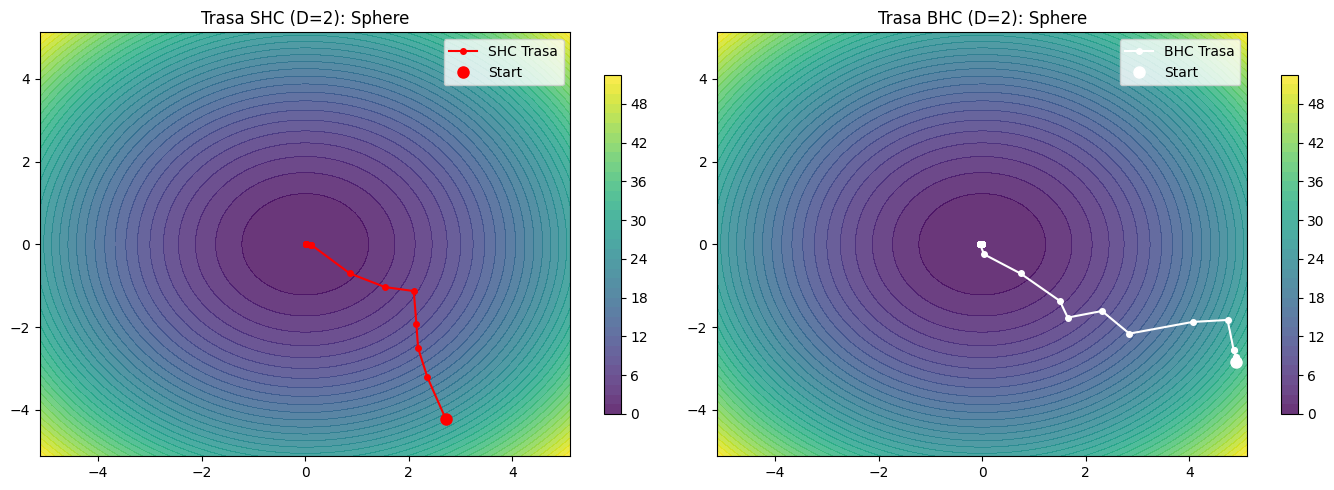

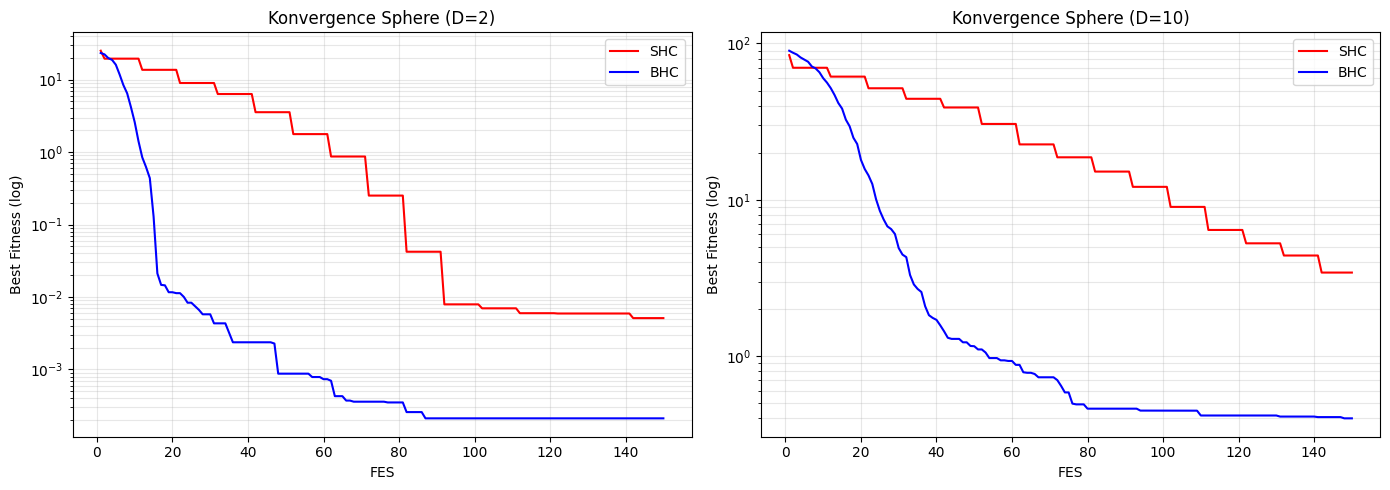


==================== Testování funkce: Rosenbrock ====================


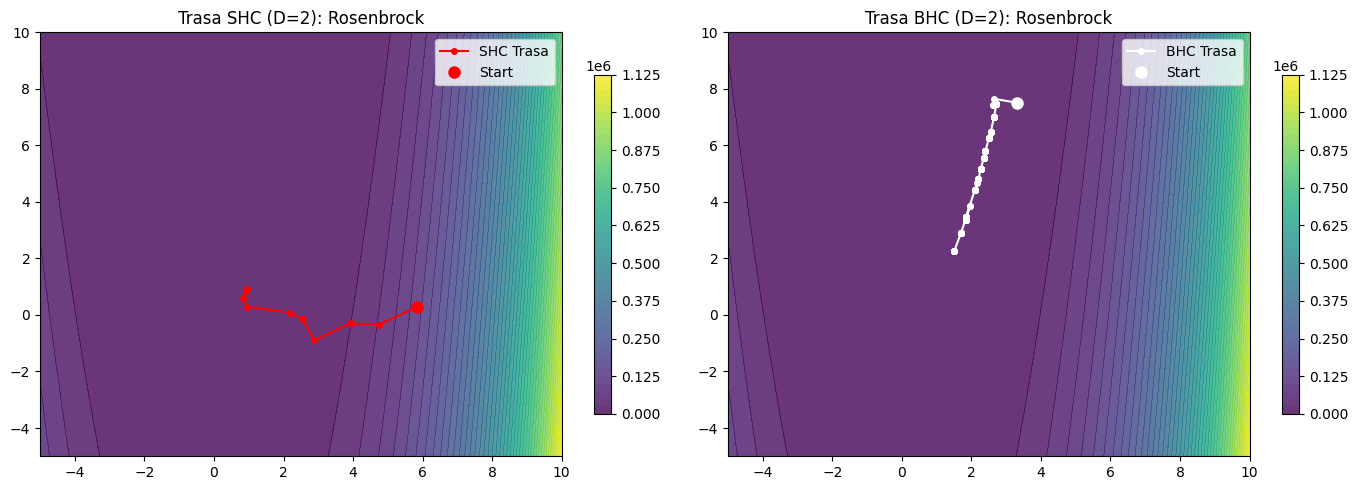

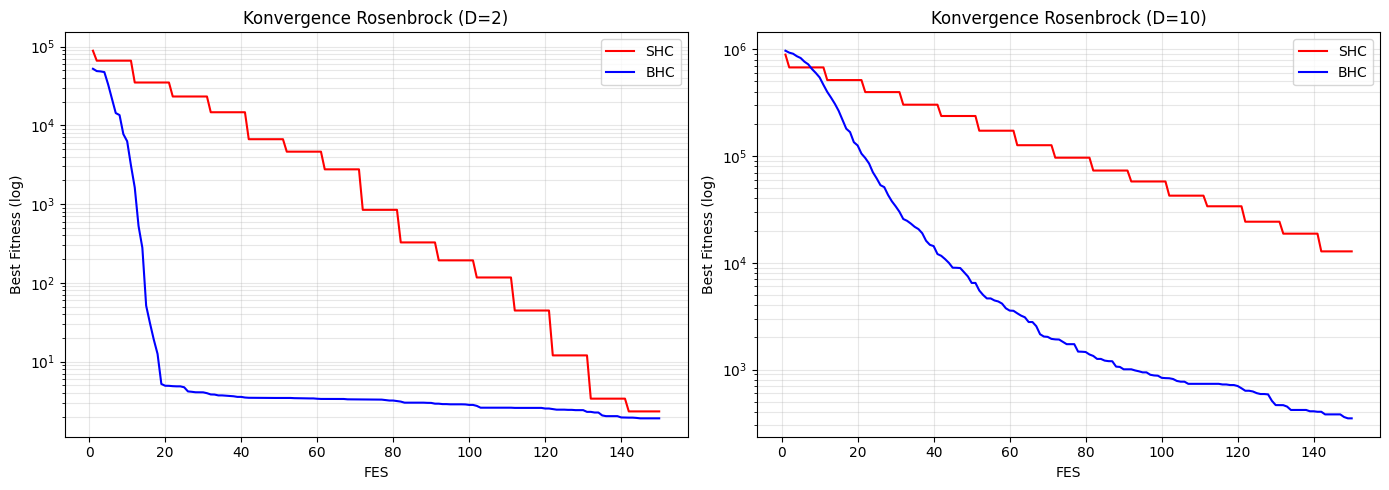


==================== Testování funkce: Rastrigin ====================


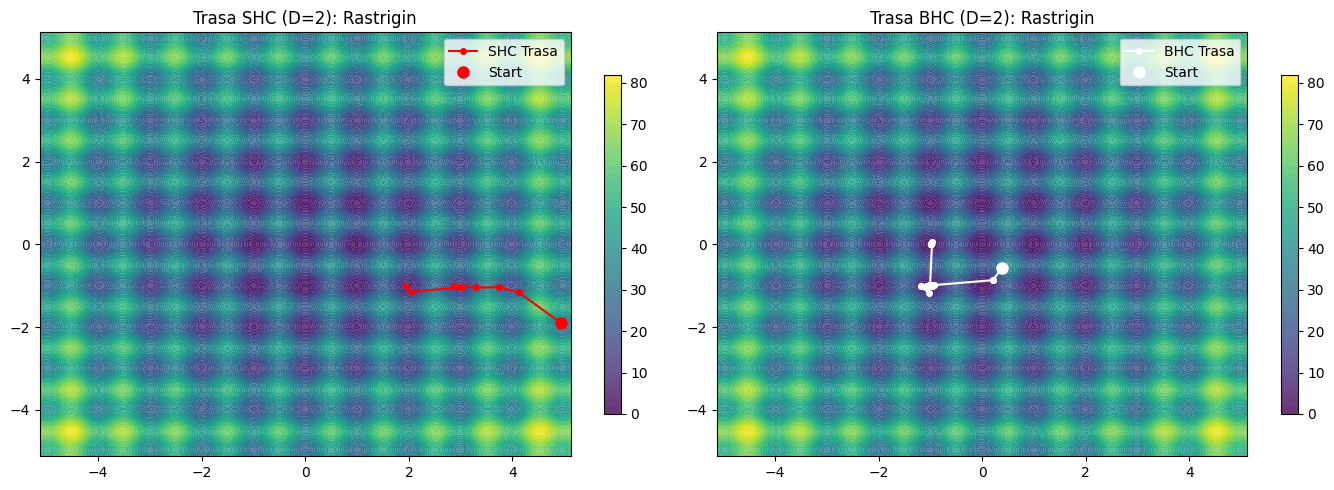

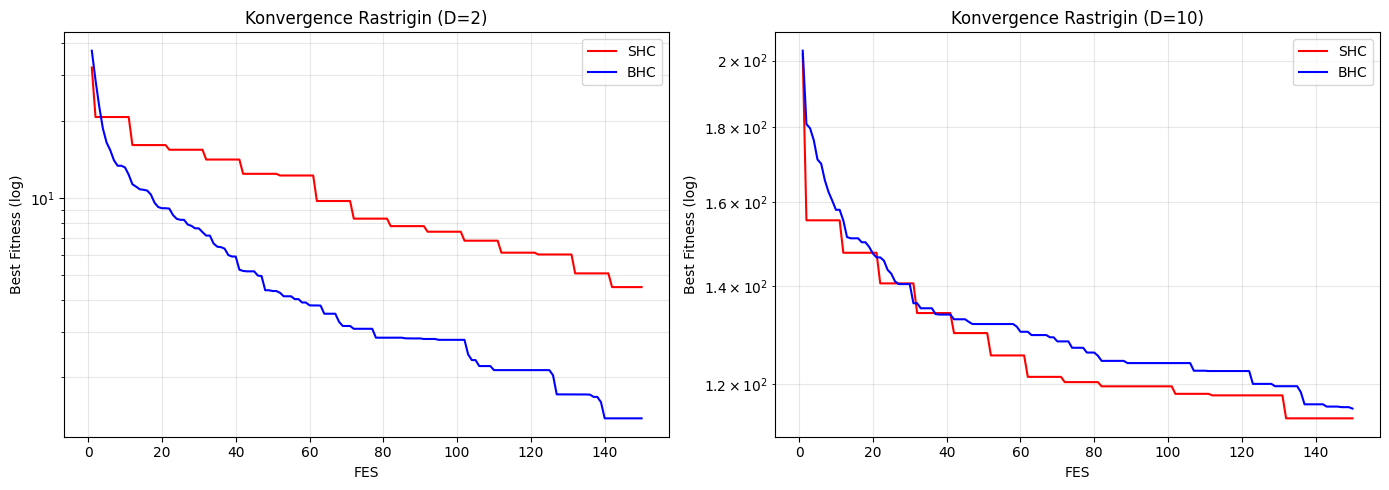


Statistické výsledky:


Funkce,Dim,Alg.,Minimum,Maximum,Průměr,Std
Sphere,2,SHC,3.9392e-04,2.0970e-02,5.1164e-03,5.7027e-03
Sphere,2,BHC,2.6683e-05,1.0652e-03,2.1170e-04,2.9573e-04
Sphere,10,SHC,1.6182e+00,7.4384e+00,3.4241e+00,1.9742e+00
Sphere,10,BHC,1.7790e-01,7.0977e-01,4.0014e-01,1.4990e-01
Rosenbrock,2,SHC,1.0731e-02,9.1218e+00,2.3340e+00,3.4044e+00
Rosenbrock,2,BHC,6.8665e-04,9.4431e+00,1.9060e+00,3.6477e+00
Rosenbrock,10,SHC,1.3220e+03,3.4335e+04,1.2787e+04,9.4201e+03
Rosenbrock,10,BHC,1.4746e+02,6.1963e+02,3.4919e+02,1.3846e+02
Rastrigin,2,SHC,6.6956e-01,8.9610e+00,4.4894e+00,2.2177e+00
Rastrigin,2,BHC,1.1570e-02,4.2972e+00,1.3833e+00,1.2439e+00



==================== Vliv parametrů na funkci Sphere (D=2) ====================


N_sousedů,Sigma,SHC Průměr,BHC Průměr
5,0.1,1.4866e+00,5.3258e-05
10,0.5,7.5501e-03,9.0710e-04
50,2.0,7.9776e-02,9.7577e-04


In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.gaussian_process import GaussianProcessRegressor
from IPython.display import display, HTML

warnings.filterwarnings('ignore')

def sphere(x):
    return np.sum(x**2, axis=-1)

def rosenbrock(x):
    return np.sum(100 * (x[..., 1:] - x[..., :-1]**2)**2 + (1 - x[..., :-1])**2, axis=-1)

def rastrigin(x):
    d = x.shape[-1]
    return 10 * d + np.sum(x**2 - 10 * np.cos(2 * np.pi * x), axis=-1)

FUNCTIONS = {
    "Sphere": (sphere, -5.12, 5.12),
    "Rosenbrock": (rosenbrock, -5.0, 10.0),
    "Rastrigin": (rastrigin, -5.12, 5.12)
}

def generate_neighbors(current_x, low, high, dim, N_neighbors, sigma):
    neighbors = np.empty((0, dim))
    while len(neighbors) < N_neighbors:
        cands = current_x + np.random.normal(0, sigma, (N_neighbors, dim))
        valid = cands[(np.all(cands >= low, axis=1)) & (np.all(cands <= high, axis=1))]
        neighbors = np.vstack((neighbors, valid))
    return neighbors[:N_neighbors]

def stochastic_hill_climber(func, dim, low, high, max_fes, N_neighbors=10, sigma=0.5):
    current_x = np.random.uniform(low, high, dim)
    current_y = func(np.array([current_x]))[0]
    
    best_y = current_y
    convergence = [best_y]
    path = [current_x.copy()]
    
    fes = 1
    while fes < max_fes:
        neighbors = generate_neighbors(current_x, low, high, dim, N_neighbors, sigma)

        evals = func(neighbors)
        evals_count = len(neighbors)
        
        best_idx = np.argmin(evals)
        if evals[best_idx] < current_y:
            current_x = neighbors[best_idx].copy()
            current_y = evals[best_idx]
            
        if current_y < best_y:
            best_y = current_y
            
        fes += evals_count
        
        convergence.extend([best_y] * evals_count)
        path.append(current_x.copy())
        
    return best_y, np.array(convergence)[:max_fes], np.array(path)

def bayesian_guided_hill_climber(func, dim, low, high, max_fes, N_neighbors=10, sigma=0.5):
    current_x = np.random.uniform(low, high, dim)
    current_y = func(np.array([current_x]))[0]
    
    X_train = [current_x.copy()]
    y_train = [current_y]
    
    best_y = current_y
    convergence = [best_y]
    path = [current_x.copy()]
    
    kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2))
    gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=0, normalize_y=True, random_state=42)
    
    fes = 1
    while fes < max_fes:
        try:
            gp.fit(X_train, y_train)
        except Exception:
            pass 
            
        candidates = generate_neighbors(current_x, low, high, dim, N_neighbors, sigma)
        
        try:
            y_pred = gp.predict(candidates)
            best_idx = np.argmin(y_pred)
        except Exception:
            best_idx = np.random.randint(0, N_neighbors)
            
        best_candidate = candidates[best_idx]
        
        true_y = func(np.array([best_candidate]))[0]
        
        X_train.append(best_candidate.copy())
        y_train.append(true_y)
        
        if true_y < current_y:
            current_x = best_candidate.copy()
            current_y = true_y
            
        if current_y < best_y:
            best_y = current_y
            
        fes += 1
        convergence.append(best_y)
        path.append(current_x.copy())
        
    return best_y, np.array(convergence)[:max_fes], np.array(path)

def plot_search_path(func, low, high, path_shc, path_bhc, title):
    fig = plt.figure(figsize=(14, 5))
    x_lin = np.linspace(low, high, 100)
    X, Y = np.meshgrid(x_lin, x_lin)
    grid = np.c_[X.ravel(), Y.ravel()]
    Z = func(grid).reshape(X.shape)
    
    ax1 = fig.add_subplot(1, 2, 1)
    cont1 = ax1.contourf(X, Y, Z, levels=50, cmap='viridis', alpha=0.8)
    fig.colorbar(cont1, ax=ax1, shrink=0.8)
    if len(path_shc) > 0:
        path_shc = np.array(path_shc)
        ax1.plot(path_shc[:, 0], path_shc[:, 1], 'r.-', label='SHC Trasa', markersize=8, linewidth=1.5)
        ax1.plot(path_shc[0, 0], path_shc[0, 1], 'ro', markersize=8, label='Start')
    ax1.set_title(f"Trasa SHC (D=2): {title}")
    ax1.legend()
    
    ax2 = fig.add_subplot(1, 2, 2)
    cont2 = ax2.contourf(X, Y, Z, levels=50, cmap='viridis', alpha=0.8)
    fig.colorbar(cont2, ax=ax2, shrink=0.8)
    if len(path_bhc) > 0:
        path_bhc = np.array(path_bhc)
        ax2.plot(path_bhc[:, 0], path_bhc[:, 1], 'w.-', label='BHC Trasa', markersize=8, linewidth=1.5)
        ax2.plot(path_bhc[0, 0], path_bhc[0, 1], 'wo', markersize=8, label='Start')
    ax2.set_title(f"Trasa BHC (D=2): {title}")
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

def run_all_experiments():
    dimensions = [2, 10]
    runs = 10
    max_fes = 150
    N_neighbors = 10
    sigma = 0.5
    
    results = []
    
    for name, (func, low, high) in FUNCTIONS.items():
        print(f"\n{'='*20} Testování funkce: {name} {'='*20}")
        shc_curves_all = {2: [], 10: []}
        bhc_curves_all = {2: [], 10: []}
        
        for d in dimensions:
            shc_bests, bhc_bests = [], []
            
            for r in range(runs):
                b_s, c_s, p_s = stochastic_hill_climber(func, d, low, high, max_fes, N_neighbors, sigma)
                b_b, c_b, p_b = bayesian_guided_hill_climber(func, d, low, high, max_fes, N_neighbors, sigma)
                
                shc_bests.append(b_s); bhc_bests.append(b_b)
                shc_curves_all[d].append(c_s); bhc_curves_all[d].append(c_b)
                
                if r == 0 and d == 2:
                    plot_search_path(func, low, high, p_s, p_b, name)
            
            results.append({
                "Funkce": name, "Dim": d, "Alg.": "SHC",
                "Minimum": f"{np.min(shc_bests):.4e}", "Maximum": f"{np.max(shc_bests):.4e}",
                "Průměr": f"{np.mean(shc_bests):.4e}", "Std": f"{np.std(shc_bests):.4e}"
            })
            results.append({
                "Funkce": name, "Dim": d, "Alg.": "BHC",
                "Minimum": f"{np.min(bhc_bests):.4e}", "Maximum": f"{np.max(bhc_bests):.4e}",
                "Průměr": f"{np.mean(bhc_bests):.4e}", "Std": f"{np.std(bhc_bests):.4e}"
            })
            
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
        for d, ax in zip(dimensions, [ax1, ax2]):
            avg_shc = np.mean(shc_curves_all[d], axis=0)
            avg_bhc = np.mean(bhc_curves_all[d], axis=0)
            fes_axis = np.linspace(1, max_fes, len(avg_shc))
            
            ax.plot(fes_axis, avg_shc, 'r-', label='SHC')
            ax.plot(fes_axis, avg_bhc, 'b-', label='BHC')
            ax.set_yscale('log')
            ax.set_title(f"Konvergence {name} (D={d})")
            ax.set_xlabel("FES")
            ax.set_ylabel("Best Fitness (log)")
            ax.legend()
            ax.grid(True, which="both", ls="-", alpha=0.3)
            
        plt.tight_layout()
        plt.show()
        
    df = pd.DataFrame(results)
    print("\nStatistické výsledky:")
    display(HTML(df.to_html(index=False, classes='table table-striped')))

def run_parameter_testing():
    print(f"\n{'='*20} Vliv parametrů na funkci Sphere (D=2) {'='*20}")
    func, low, high = FUNCTIONS["Sphere"]
    max_fes = 100
    runs = 5
    variations = [ {"N": 5, "sigma": 0.1}, {"N": 10, "sigma": 0.5}, {"N": 50, "sigma": 2.0} ]
    
    results = []
    for var in variations:
        N, sig = var["N"], var["sigma"]
        shc_bests, bhc_bests = [], []
        for r in range(runs):
            bs, _, _ = stochastic_hill_climber(func, 2, low, high, max_fes, N, sig)
            bb, _, _ = bayesian_guided_hill_climber(func, 2, low, high, max_fes, N, sig)
            shc_bests.append(bs); bhc_bests.append(bb)
            
        results.append({
            "N_sousedů": N, "Sigma": sig,
            "SHC Průměr": f"{np.mean(shc_bests):.4e}", "BHC Průměr": f"{np.mean(bhc_bests):.4e}"
        })
        
    df = pd.DataFrame(results)
    display(HTML(df.to_html(index=False, classes='table table-striped')))

run_all_experiments()
run_parameter_testing()


## Komentář

**Nastavení experimentů:**
* **Intervaly testovacích funkcí:** Sphere $[-5.12, 5.12]$, Rosenbrock $[-5, 10]$, Rastrigin $[-5.12, 5.12]$
* **Maximální počet evaluací (FES):** 150
* **Počet generovaných sousedů (N):** 10
* **Velikost okolí ($\sigma$):** 0.5
* **Počet nezávislých běhů:** 10

**Sphere** slouží jako základní benchmark pro ověření rychlosti konvergence. V obou dimenzích (2D i 10D) vykazuje nejhladší průběh hledání. Modelově řízený přístup (BHC) zde těží z vysoké korelace bodů, což umožňuje Gaussian procesu velmi přesně odhadnout polohu minima i při nízkém počtu reálných vyhodnocení.

**Rosenbrock** je charakteristický svým úzkým údolím. Pro klasický SHC je tato funkce problematická, protože náhodné generování sousedů málokdy trefí směr úzkého zakřivení. BHC vykazuje v 2D stabilitu, ale v 10D naráží na komplexnost terénu, přesto si však díky paměti předchozích bodů vede efektivněji než čistá náhodnost.

**Rastrigin** představuje největší výzvu kvůli vysokému počtu lokálních minim. Zatímco SHC často uvízne v nejbližším důlku, BHC díky predikci surrogate modelu dokáže některé lokální pasti přeskočit, protože model identifikuje oblasti s nižším očekávaným fitness dříve, než do nich investuje drahé evaluace.

---

Z naměřených výsledků pro 10 nezávislých běhů vyplývá, že s rostoucí dimenzí (přechod z $D=2$ na $D=10$) u obou algoritmů dochází k nárůstu průměrné nalezené hodnoty. U algoritmu SHC je patrná vysoká směrodatná odchylka, což potvrzuje jeho značnou závislost na náhodné inicializaci a náhodném výběru sousedů. BHC naopak vykazuje stabilnější konvergenci k optimu v čase.

---

Z celkového porovnání vyplývá, že lepších výsledků dosáhl algoritmus Bayesian-guided Hill Climber (BHC). Hlavním důvodem je jeho schopnost vytěžit maximum informací z každé evaluace. Zatímco SHC spotřebuje celý rozpočet N evaluací v každém kroku pro prosté srovnání sousedů, BHC vyhodnocuje reálně pouze jeden, modelem predikovaný bod. To mu umožňuje provést v rámci fixního rozpočtu (150 FES) mnohem více kroků v prostoru řešení. Zejména ve vyšších dimenzích BHC vykazuje stabilnější chování a nalezené hodnoty účelové funkce konvergují rychleji ke globálnímu optimu.

**Vliv parametrů na algoritmy:**
* **Velikost okolí ($\sigma$):** Pro oba algoritmy je kritická. Příliš velká hodnota způsobuje, že se algoritmus chová jako Random Search a ztrácí schopnost lokálního doladění. Malá hodnota naopak vede k předčasné stagnaci v lokálním optimu.
* **Počet sousedů (N):** U SHC má N přímý negativní dopad na počet iterací (čím více sousedů, tím méně kroků lze udělat). U BHC zvýšení N zvyšuje kvalitu výběru v každém kroku, aniž by se vyčerpával rozpočet evaluací účelové funkce, což výrazně zvyšuje robustnost hledání.
